In [ ]:
#!conda install conda-forge::eqcorrscan --yes

In [ ]:
#!conda install conda-forge::obsplus --yes

In [16]:
import numpy as np
import eqcorrscan
import pandas as pd
from tqdm import tqdm
from pathlib import Path

from eqcorrscan import Tribe
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.core.event import (
    Catalog, Event, Pick, WaveformStreamID, Origin)
from obspy.geodetics import gps2dist_azimuth
from obspy import read
from obspy.core.inventory import (Inventory, Network, Station, Channel, 
                                   Site, Response)
from obspy.core.util import AttribDict
from collections import defaultdict



from parallel_download import download_miniseed_parallel

Get inventory

In [17]:
client = Client("IRIS")
inventory = client.get_stations(starttime=UTCDateTime(2014, 7, 17),
    endtime=UTCDateTime(2014, 7, 19),
    latitude=46.2, longitude=-122.19,
    maxradius=0.25, channel='HHZ', level='channel')

List inventory

In [18]:
# convert inventory to dataframe used for downloading miniseed files
data = []
for network in inventory:
    for station in network:
        data.append({
            "network": network.code,
            "station": station.code,
            "latitude": station.latitude,
            "longitude": station.longitude,
            "elevation": station.elevation,
            "start_date": station.start_date,
            "end_date": station.end_date
        })

# Create DataFrame
df_query = pd.DataFrame(data)
# display(df_query)

Read IMUSH.csv and turn into dataframe

In [19]:
# this code is optional,converting the inventory to a dataframe to compare against IMUSH.csv

df_imush = pd.read_csv('IMUSH.csv')

merged_df = pd.merge(df_query, df_imush, on='station', how='inner')
merged_df = merged_df.drop(['start', 'end','latitude_y', 'longitude_y', 'elevation_y', 'site', 'datacenter'], axis=1)
merged_df = merged_df.rename(columns={"latitude_x": "latitude", "longitude_x": "longitude", "elevation_x": "elevation"})

# display(merged_df)

Convert dataframe back to catalog

In [20]:
# this code is optional,converting the inventory to a dataframe to compare against IMUSH.csv

import pandas as pd
from obsplus.utils.stations import df_to_inventory

# Assume 'stations_df' is your pre-formatted DataFrame
# stations_df = pd.DataFrame(...)

# Convert the DataFrame to an ObsPy Inventory object
imush_inventory = df_to_inventory(merged_df)

Download miniseed files that match Alicias example and are in the IMUSH data

In [21]:
# Download data with parallelism, function is imported from parallel_download.py

results = download_miniseed_parallel(
    df_query.itertuples(),
    starttime='2014-07-17',
    endtime='2014-07-19',  # One day of data
    output_dir='./cross_correlation_data',
    max_workers=10  # Process 10 stations simultaneously
)

Output directory: ./cross_correlation_data
Initialized IRIS/EarthScope client
Preparing to download 26 stations with 10 parallel workers

✗ Failed to download MG07: No data available for request.
HTTP Status code: 204
Detailed response of server:


✓ Successfully saved to: ./cross_correlation_data/XD_MG05_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MI08_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MH04_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MG06_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MI05_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MF05_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MG03_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MI04_20140717_20140719.mseed
✓ Successfully saved to: ./cross_correlation_data/XD_MI09_20140717_20140719.mseed
✓ Successfull

In [ ]:
# create station.xml from downloaded miniseed files

def create_basic_station_xml(miniseed_dir, output_file='station.xml'):

    miniseed_path = Path(miniseed_dir)
    
    # Find all miniseed files
    mseed_files = list(miniseed_path.glob('*.mseed'))
    
    # Collect station information
    station_data = defaultdict(lambda: defaultdict(list))
    
    for mseed_file in tqdm(mseed_files, desc="Reading files"):
        try:
            st = read(str(mseed_file), headonly=True)
            
            for tr in st:
                net = tr.stats.network
                sta = tr.stats.station
                loc = tr.stats.location
                cha = tr.stats.channel
                
                station_data[net][sta].append({
                    'location': loc,
                    'channel': cha,
                    'sampling_rate': tr.stats.sampling_rate,
                    'starttime': tr.stats.starttime,
                    'endtime': tr.stats.endtime
                })
                
        except Exception as e:
            tqdm.write(f"Error reading {mseed_file.name}: {e}")
            continue
    
    # Create inventory
    inventory = Inventory(networks=[], source="Miniseed Files")
    
    for net_code in station_data:
        # Create network
        network = Network(code=net_code)
        
        for sta_code in station_data[net_code]:
            # Create station with minimal info
            station = Station(
                code=sta_code,
                latitude=0.0,  # Unknown
                longitude=0.0,  # Unknown
                elevation=0.0,  # Unknown
                site=Site(name="Unknown")
            )
            
            # Group channels by location
            loc_channels = defaultdict(list)
            for chan_info in station_data[net_code][sta_code]:
                loc_channels[chan_info['location']].append(chan_info)
            
            # Create channels
            for loc, channels in loc_channels.items():
                for chan_info in channels:
                    channel = Channel(
                        code=chan_info['channel'],
                        location_code=loc if loc else "",
                        latitude=0.0,
                        longitude=0.0,
                        elevation=0.0,
                        depth=0.0,
                        sample_rate=chan_info['sampling_rate'],
                        start_date=chan_info['starttime'],
                        end_date=chan_info['endtime']
                    )
                    station.channels.append(channel)
            
            network.stations.append(station)
        
        inventory.networks.append(network)
    
    # Write to XML
    # inventory.write(output_file, format='STATIONXML')
    # print(f"\\nBasic station XML saved to: {output_file}")
    # print(f"Networks: {len(inventory)}")
    # print(f"Stations: {sum(len(net) for net in inventory)}")
    
    return inventory

# create station.xml from the downloaded 
create_basic_station_xml( miniseed_dir='./cross_correlation_data', output_file='./cross_correlation_data/station.xml')

Found 25 miniseed files


Reading files: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 235.82it/s]


Inventory created at 2026-03-05T03:16:38.130048Z
	Created by: ObsPy 1.4.2
		    https://www.obspy.org
	Sending institution: Miniseed Files
	Contains:
		Networks (1):
			XD
		Stations (25):
			XD.MF05 (Unknown)
			XD.MG03 (Unknown)
			XD.MG05 (Unknown)
			XD.MG06 (Unknown)
			XD.MG08 (Unknown)
			XD.MH04 (Unknown)
			XD.MH07 (Unknown)
			XD.MI04 (Unknown)
			XD.MI05 (Unknown)
			XD.MI07 (Unknown)
			XD.MI08 (Unknown)
			XD.MI09 (Unknown)
			XD.MJ06 (Unknown)
			XD.MJ07 (Unknown)
			XD.MJ09 (Unknown)
			XD.MK04 (Unknown)
			XD.MK06 (Unknown)
			XD.MK07 (Unknown)
			XD.MK08 (Unknown)
			XD.ML07 (Unknown)
			XD.ML09 (Unknown)
			XD.MM04 (Unknown)
			XD.MM06 (Unknown)
			XD.MM08 (Unknown)
			XD.MN07 (Unknown)
		Channels (35):
			XD.MF05..HHZ, XD.MG03..HHZ (2x), XD.MG05..HHZ (2x), 
			XD.MG06..HHZ (2x), XD.MG08..HHZ, XD.MH04..HHZ (2x), 
			XD.MH07..HHZ (2x), XD.MI04..HHZ (2x), XD.MI05..HHZ (2x), 
			XD.MI07..HHZ, XD.MI08..HHZ, XD.MI09..HHZ (2x), XD.MJ06..HHZ, 
			XD.MJ07..HHZ, XD.MJ09..HHZ (

Get events

In [23]:
# get catalog of events

client = Client("USGS")
catalog = client.get_events(
    starttime=UTCDateTime(2014, 7, 17),
    endtime=UTCDateTime(2014, 7, 19),
    latitude=46.2, longitude=-122.19,
    maxradius=0.25)

print(catalog.count())

17


Add known event to catalog

In [24]:
event_solo = Event()
event_solo.origins = [Origin()]
event_solo.origins[0].time = UTCDateTime('2014-07-25T16:57:57.08') - 2  # assume about 2 seconds from origin to trigger time
event_solo.origins[0].latitude = 46.2
event_solo.origins[0].longitude = -122.19
event_solo.origins[0].depth = 2000

# Append to the catalog
catalog += event_solo

# print(catalog)
# print(catalog.__str__(print_all=True))

print(catalog.count())

18


Add picks

In [ ]:
# Loop over events and create picks for each channel based on distance of the station from source
# and a very simple assumption of 5 km/s wave speed. Could be more fancy by doing wave tracing
# through an actual velocity structure, but I'm just doing a rough first pass.

p_vel = 5000  # m/s 
for event in catalog:
    picks = []
    for channel in inventory.get_contents()['channels']:
        # XD (iMUSH deployment) broadbands have LHZ, BHZ, and HHZ channels; we only need HHZ
        if channel[:2] == 'XD' and channel[-3:] == 'HHZ':
            distance = np.sqrt(gps2dist_azimuth(
                event.origins[0].latitude,
                event.origins[0].longitude,
                inventory.get_channel_metadata(channel)['latitude'],
                inventory.get_channel_metadata(channel)['longitude']
            )[0]**2 + (event.origins[0].depth + inventory.get_channel_metadata(channel)['elevation'])**2)
            picks += [
                Pick(
                    time=event.origins[0].time +  distance/p_vel,
                    waveform_id=WaveformStreamID(
                        network_code=channel.split('.')[0],
                        station_code=channel.split('.')[1],
                        channel_code=channel.split('.')[3],
                        location_code=channel.split('.')[2],
                    ),
                    phase_hint='P'
                )
            ]
    event.picks = picks
print(len(event.picks))

# write a new catalog with event picks
# catalog.write("./cross_correlation_data/output_catalog.xml", format="QUAKEML")

# print(catalog.__str__(print_all=True))

26
18 Event(s) in Catalog:
2014-07-18T22:48:15.530000Z | +46.201, -122.181 | -0.47 mh | manual
2014-07-18T21:34:55.770000Z | +46.199, -122.183 | 0.35 ml | manual
2014-07-18T06:08:15.750000Z | +46.200, -122.198 | -0.31 mh | manual
2014-07-18T06:07:15.470000Z | +46.202, -122.201 | -0.22 mh | manual
2014-07-18T03:26:32.930000Z | +46.142, -122.163 | 0.0  md | manual
2014-07-18T00:31:47.200000Z | +46.200, -122.176 | -0.3  mh | manual
2014-07-17T21:50:20.370000Z | +46.190, -122.123 | -0.14 mh | manual
2014-07-17T20:24:49.000000Z | +46.200, -122.179 | 0.29 ml | manual
2014-07-17T20:22:03.670000Z | +46.197, -122.172 | -0.36 mh | manual
2014-07-17T19:53:37.290000Z | +46.194, -122.186 | -0.12 mh | manual
2014-07-17T19:30:26.160000Z | +46.200, -122.188 | -0.28 mh | manual
2014-07-17T19:26:16.270000Z | +46.197, -122.177 | -0.14 mh | manual
2014-07-17T19:12:12.210000Z | +46.303, -122.227 | -0.5  md | manual
2014-07-17T17:42:17.610000Z | +46.200, -122.181 | 0.26 ml | manual
2014-07-17T15:07:17.38000

In [26]:
catalog.write("./cross_correlation_data/output_catalog.xml", format="QUAKEML")

/Users/sophiaparafina/miniconda3/lib/python3.12/site-packages/obspy/io/quakeml/core.py:1112: UserWarning: 'quakeml:earthquake.usgs.gov/fdsnws/event/1/query?starttime=2014-07-17T00%3A00%3A00.000000&endtime=2014-07-19T00%3A00%3A00.000000&latitude=46.2&longitude=-122.19&maxradius=0.25' is not a valid QuakeML URI. It will be in the final file but note that the file will not be a valid QuakeML file.
  warnings.warn(msg % obj.id)


In [ ]:
# Make the templates with eqcorrscan

# We're constructing templates with a 10-second window to capture P and S with a bit of filtering.
# These can all be adjusted but should match the filtering and processing length you plan to use to
# scan through the continuous data. 

# There are a lot of stations and quite a few possible channels (40+)... we can reduce the search space if needed
import os
import obspy

# stream composed of downloaded miniseed files
st = read('./cross_correlation_data/*.mseed')

# parameters for construct function: https://eqcorrscan.readthedocs.io/en/latest/submodules/core.match_filter.tribe.html#eqcorrscan.core.match_filter.tribe.Tribe.construct
tribe = Tribe().construct(
    method="from_meta_file",
    catalog="./cross_correlation_data/output_catalog.xml",
    st=st,
    process=True,
    lowcut=1.0,
    highcut=10.0,
    samp_rate=50.0,
    filt_order=4,
    length=10.0,
    prepick=1,
    process_len=86400,
    all_horiz=False,
    parallel=True,
    min_snr=3.0,
)

print(len(tribe))


AttributeError: 'str' object has no attribute 'picks'

In [22]:
client = Client("IRIS")

party = tribe.client_detect(
    client=client,
    starttime=UTCDateTime(2014,7,15),
    endtime=UTCDateTime(2014,8,10),
    threshold=10,
    threshold_type="MAD",
    trig_int=1.0,
    concurrent_processing=True,
)

Streams in queue will be edited in-place, you should not re-use them
Last bit of data between 2014-07-16T00:00:00.000000Z and 2014-07-16T00:00:20.005000Z will go unused because it is shorter than a chunk of 86400.0 s
/Users/sophiaparafina/miniconda3/lib/python3.12/site-packages/eqcorrscan/utils/correlate.py:980: RuntimeWarning: invalid value encountered in divide
  (template_array[seed_id] -
Removed data for XD.MI07..HHZ XD.MK06..HHZ XD.ML09..HHZ due to less than 80% of the required length.
Last bit of data between 2014-07-16T23:59:53.500000Z and 2014-07-17T00:00:13.495000Z will go unused because it is shorter than a chunk of 86400.0 s
Last bit of data between 2014-07-17T23:59:46.990000Z and 2014-07-18T00:00:06.995000Z will go unused because it is shorter than a chunk of 86400.0 s
Out-of-range correlation in C-code, see WARNING from C-code.You are STRONGLY RECOMMENDED to check your data for spikes, clipping or non-physical artifacts
Low variance found in 8902 places for XD.MG06..HHZ_3,

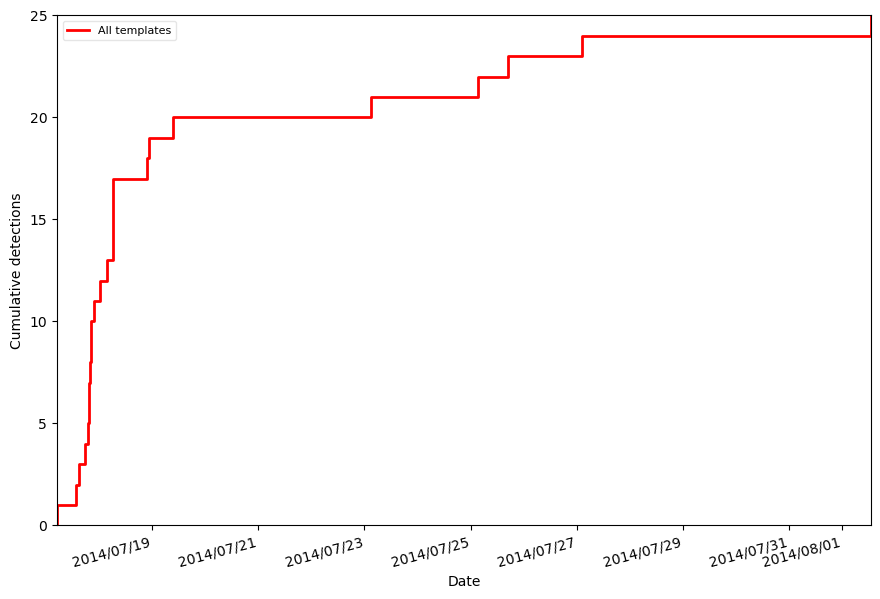

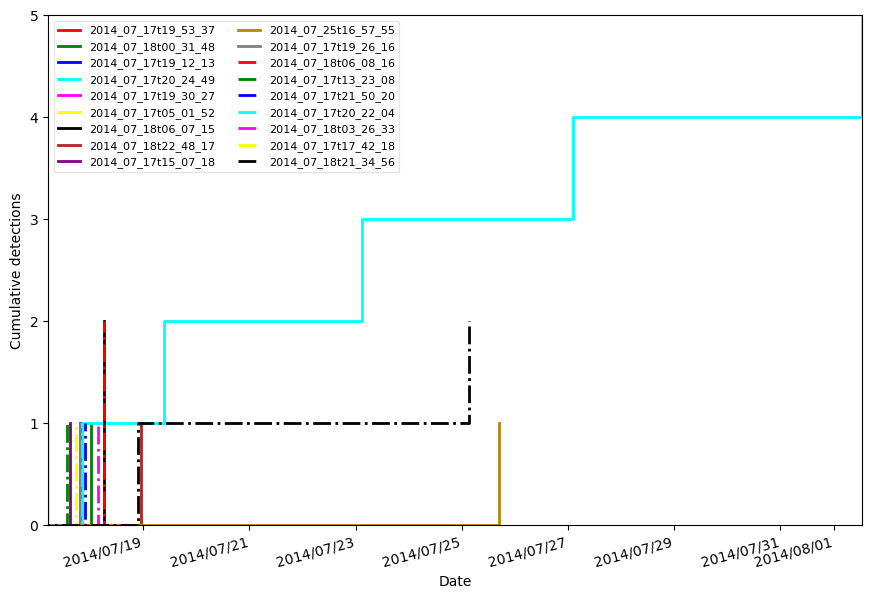

Number of templates: 18
Number of additional detections: 7


In [23]:
party.plot(plot_grouped=True)
party.plot(plot_grouped=False)

print(f'Number of templates: {len(tribe)}')
print(f'Number of additional detections: {len(party)-len(tribe)}')